<a href="https://colab.research.google.com/github/karrielaugustin001-del/Machine-Learning-Foundations/blob/main/From_Raw_Text_to_Sentiment_Classifier_Student_MRL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In Class Activity
## Activity Title: From Raw Text to Sentiment Classifier

**Purpose:** To give students hands-on experience with the full NLP pipeline—from preprocessing to modeling—while reinforcing the week’s learning objectives.

**Resources Provided**
- `dataset/movie_reviews_large.csv`
- `scripts/starter_script.py`
- Student starter notebook with TODOs
- Colab notebook version
- Instructor executed notebook

## Objective
Students will clean raw text, engineer features using Bag-of-Words and TF-IDF, train a sentiment classifier, evaluate performance, and reflect on bias and fairness in NLP.

## Step 1: Group Formation (5 minutes)
Divide students into groups of 3–4.
Suggested roles:
- Data Loader
- Preprocessing Lead
- Modeling Lead
- Discussion Recorder

In [3]:
import nltk, re, pandas as pd, numpy as np
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Step 2: Hands-On Implementation
Load the dataset using `pd.read_csv('dataset/movie_reviews_large.csv')`. Review attributes, structure, and variables.

In [47]:
df = pd.read_csv("movie_reviews_large.csv")
# Remove duplicate reviews based on 'review_text', keeping the first occurrence
df = df.drop_duplicates(subset=['review_text'], keep='first')
df.reset_index(drop=True, inplace=True)
df.head()

,review_id,review_text,sentiment,source,domain,length_chars,dialect_flag,split_hint
0,RVW-100000,I loved the episode; the plot was fantastic an...,positive,streaming,sci-fi,84,0,train_like
1,RVW-100001,Absolutely engaging movie. The ending stood ou...,positive,theater,family,96,1,test_like
2,RVW-100002,I loved the show; the dialogue was fantastic a...,positive,review_site,drama,90,0,train_like
3,RVW-100003,Overall a weak experience because the characte...,negative,social_media,action,112,1,train_like
4,RVW-100004,I disliked the documentary; the plot was weak ...,negative,classroom_sample,action,108,1,train_like


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3608 entries, 0 to 3607
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review_id     3608 non-null   object
 1   review_text   3608 non-null   object
 2   sentiment     3608 non-null   object
 3   source        3608 non-null   object
 4   domain        3608 non-null   object
 5   length_chars  3608 non-null   int64 
 6   dialect_flag  3608 non-null   int64 
 7   split_hint    3608 non-null   object
dtypes: int64(2), object(6)
memory usage: 225.6+ KB


In [49]:
df["sentiment"].value_counts(), df[["source", "domain", "dialect_flag"]].head()

(sentiment
 positive    2028
 negative    1580
 Name: count, dtype: int64,
              source  domain  dialect_flag
 0         streaming  sci-fi             0
 1           theater  family             1
 2       review_site   drama             0
 3      social_media  action             1
 4  classroom_sample  action             1)

### Part 1 — Text Preprocessing Lab (LO: Preprocessing Techniques)
Tasks:
- Tokenize text
- Remove stop words
- Apply stemming and lemmatization
- Compare outputs and discuss differences

**Instructor Cue**
- What differences do you notice between stemmed and lemmatized text?
- How might these differences affect model performance?

In [6]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def normalize_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

def tokenize_and_remove_stopwords(text: str):
    text = normalize_text(text)
    tokens = word_tokenize(text)
    return [tok for tok in tokens if tok not in stop_words]

def stem_tokens(tokens):
    return [stemmer.stem(tok) for tok in tokens]

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(tok) for tok in tokens]

In [50]:
df["tokens"] = df["review_text"].apply(tokenize_and_remove_stopwords)
df["stemmed_text"] = df["tokens"].apply(lambda x: " ".join(stem_tokens(x)))
df["lemmatized_text"] = df["tokens"].apply(lambda x: " ".join(lemmatize_tokens(x)))
df[["review_text", "stemmed_text", "lemmatized_text"]].head(10)

,review_text,stemmed_text,lemmatized_text
0,I loved the episode; the plot was fantastic an...,love episod plot fantast overal experi felt amaz,loved episode plot fantastic overall experienc...
1,Absolutely engaging movie. The ending stood ou...,absolut engag movi end stood would recommend l...,absolutely engaging movie ending stood would r...
2,I loved the show; the dialogue was fantastic a...,love show dialogu fantast overal experi felt h...,loved show dialogue fantastic overall experien...
3,Overall a weak experience because the characte...,overal weak experi charact develop poorli exec...,overall weak experience character development ...
4,I disliked the documentary; the plot was weak ...,dislik documentari plot weak whole experi felt...,disliked documentary plot weak whole experienc...
5,I loved the episode; the soundtrack was fantas...,love episod soundtrack fantast overal experi f...,loved episode soundtrack fantastic overall exp...
6,Overall a forgettable experience because the c...,overal forgett experi charact develop poorli e...,overall forgettable experience character devel...
7,This movie was amazing; the character developm...,movi amaz charact develop made easi enjoy star...,movie amazing character development made easy ...
8,This film was forgettable; the plot made it di...,film forgett plot made difficult enjoy,film forgettable plot made difficult enjoy
9,Absolutely heartwarming movie. The ending stoo...,absolut heartwarm movi end stood would recomme...,absolutely heartwarming movie ending stood wou...


### Part 2 — Feature Engineering Lab (LO: Feature Extraction)
Tasks:
- Create Bag-of-Words representation
- Generate TF-IDF vectors
- Compare sparsity and interpretability

**Discussion Prompt:** How does TF-IDF change the importance of common vs. rare words?

In [52]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
bow = CountVectorizer(max_features=3000, ngram_range=(1, 2))
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

X_train_bow = bow.fit_transform(X_train_raw_text)
X_test_bow = bow.transform(X_test_raw_text)

X_train_tfidf = tfidf.fit_transform(X_train_raw_text)
X_test_tfidf = tfidf.transform(X_test_raw_text)

print("BoW train shape:", X_train_bow.shape)
print("BoW test shape:", X_test_bow.shape)
print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

# Recalculate sparsity based on the full X_bow and X_tfidf matrices (all data transformed for consistency in this display)
# Note: These sparsity calculations are for the *transformed* training data, which is now representative.
print("BoW sparsity (training data):", 1 - (X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])))
print("TF-IDF sparsity (training data):", 1 - (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])))

BoW train shape: (2886, 573)
BoW test shape: (722, 573)
TF-IDF train shape: (2886, 573)
TF-IDF test shape: (722, 573)
BoW sparsity (training data): 0.9700286270966899
TF-IDF sparsity (training data): 0.9700286270966899


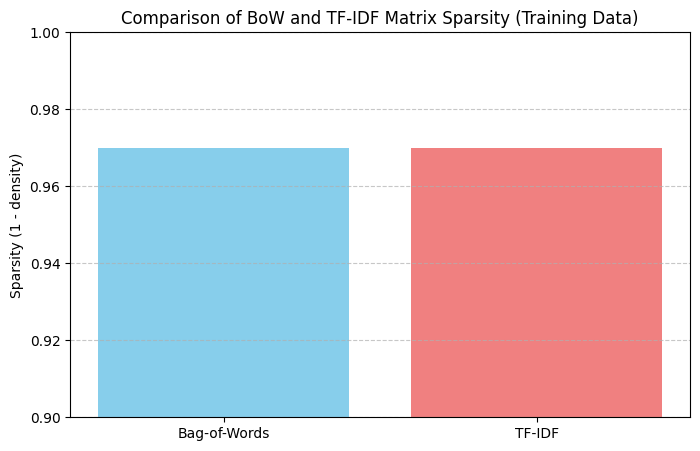

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# Extracting sparsity values from the newly fitted X_train_bow and X_train_tfidf
bow_sparsity = 1 - (X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]))
tfidf_sparsity = 1 - (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))

specific_sparsity = pd.DataFrame({
    'Vectorization Method': ['Bag-of-Words', 'TF-IDF'],
    'Sparsity': [bow_sparsity, tfidf_sparsity]
})

plt.figure(figsize=(8, 5))
plt.bar(specific_sparsity['Vectorization Method'], specific_sparsity['Sparsity'], color=['skyblue', 'lightcoral'])
plt.ylabel('Sparsity (1 - density)')
plt.title('Comparison of BoW and TF-IDF Matrix Sparsity (Training Data)')
plt.ylim(0.9, 1.0) # Set y-axis limits to better visualize high sparsity
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This bar chart visually confirms that both Bag-of-Words and TF-IDF matrices exhibit very high levels of sparsity (close to 1). This is common in natural language processing because most documents contain only a small subset of the entire vocabulary, leading to many zero entries in their vector representations.

In [54]:
import pandas as pd

# Convert the sparse BoW matrix for the *training* dataset to a dense array for easier viewing
bow_dense_df = pd.DataFrame(X_train_bow.toarray(), columns=bow.get_feature_names_out())

print("First 5 rows of the Bag-of-Words matrix (training data, for display):")
display(bow_dense_df.head())

First 5 rows of the Bag-of-Words matrix (training data, for display):


,absolutely,absolutely amazing,absolutely engaging,absolutely excellent,absolutely heartwarming,absolutely impressive,absolutely memorable,absolutely outstanding,acting,acting fantastic,...,weak soundtrack,weak vibe,weak whole,whole,whole experience,whole time,wild,wild real,would,would recommend
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,0,0


In [ ]:
feature_names = tfidf.get_feature_names_out()[:30]
feature_names

array(['absolutely', 'absolutely amazing', 'absolutely engaging',
       'absolutely excellent', 'absolutely heartwarming',
       'absolutely impressive', 'absolutely memorable',
       'absolutely outstanding', 'acting', 'acting fantastic',
       'acting made', 'acting poorly', 'acting stood', 'acting weak',
       'amazing', 'amazing acting', 'amazing cap', 'amazing character',
       'amazing dialogue', 'amazing documentary', 'amazing editing',
       'amazing ending', 'amazing episode', 'amazing film',
       'amazing honestly', 'amazing kinda', 'amazing lowkey',
       'amazing movie', 'amazing plot', 'amazing review'], dtype=object)

In [55]:
import pandas as pd

# Convert the sparse TF-IDF matrix for the *training* dataset to a dense array for easier viewing
tfidf_dense_df = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf.get_feature_names_out())

print("First 5 rows of the TF-IDF matrix (training data, for display):")
display(tfidf_dense_df.head())

First 5 rows of the TF-IDF matrix (training data, for display):


,absolutely,absolutely amazing,absolutely engaging,absolutely excellent,absolutely heartwarming,absolutely impressive,absolutely memorable,absolutely outstanding,acting,acting fantastic,...,weak soundtrack,weak vibe,weak whole,whole,whole experience,whole time,wild,wild real,would,would recommend
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.209265,0.185145,0.209265,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.210087,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.209784,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.205936,0.182199,0.205936,0.0,0.0,0.0,0.0,0.0


In [56]:
import numpy as np

# Select a few sample review indices from the *original* df to demonstrate
# We'll re-transform their lemmatized text using the fitted tfidf vectorizer
sample_review_indices = [0, 1, 2, 3] # Using indices from the head() output of the *original* df before deduplication

print("Top TF-IDF Features for Sample Reviews (from original dataset, re-transformed with fitted vectorizer):\n")

# Get the lemmatized text for these original indices from the deduplicated df
sample_lemmatized_texts = df['lemmatized_text'].iloc[sample_review_indices]

for i, idx_in_deduplicated_df in enumerate(sample_review_indices):
    original_review_text = df['review_text'].iloc[idx_in_deduplicated_df]
    lemmatized_review = df['lemmatized_text'].iloc[idx_in_deduplicated_df]

    # Transform the individual lemmatized review text using the *fitted* tfidf vectorizer
    individual_tfidf_vector = tfidf.transform([lemmatized_review])
    tfidf_scores = pd.Series(individual_tfidf_vector.toarray().flatten(), index=tfidf.get_feature_names_out())

    # Get the features with non-zero TF-IDF scores, sorted in descending order
    top_features = tfidf_scores[tfidf_scores > 0].sort_values(ascending=False)

    print(f"--- Sample Review {i} (Original index {idx_in_deduplicated_df}) ---")
    print(f"Original Review: {original_review_text}")
    print(f"Lemmatized: {lemmatized_review}")
    print("Top 10 TF-IDF Features:")
    display(top_features.head(10))
    print("\n")

Top TF-IDF Features for Sample Reviews (from original dataset, re-transformed with fitted vectorizer):

--- Sample Review 0 (Original index 0) ---
Original Review: I loved the episode; the plot was fantastic and the overall experience felt amazing.
Lemmatized: loved episode plot fantastic overall experience felt amazing
Top 10 TF-IDF Features:


,0
episode plot,0.425218
loved episode,0.360468
plot fantastic,0.351418
felt amazing,0.350475
amazing,0.267958
episode,0.231445
plot,0.229480
overall experience,0.203820
loved,0.203820
fantastic,0.203820




--- Sample Review 1 (Original index 1) ---
Original Review: Absolutely engaging movie. The ending stood out and I would recommend it. This was low-key good.
Lemmatized: absolutely engaging movie ending stood would recommend lowkey good
Top 10 TF-IDF Features:


,0
engaging movie,0.402943
movie ending,0.344827
recommend lowkey,0.326745
absolutely engaging,0.296821
ending stood,0.295191
engaging,0.229204
lowkey good,0.218340
lowkey,0.218340
good,0.218340
movie,0.189535




--- Sample Review 2 (Original index 2) ---
Original Review: I loved the show; the dialogue was fantastic and the overall experience felt heartwarming.
Lemmatized: loved show dialogue fantastic overall experience felt heartwarming
Top 10 TF-IDF Features:


,0
show dialogue,0.413473
dialogue fantastic,0.362088
felt heartwarming,0.355910
loved show,0.350191
heartwarming,0.273801
show,0.232086
dialogue,0.229159
fantastic,0.204736
loved,0.204736
overall experience,0.204736




--- Sample Review 3 (Original index 3) ---
Original Review: Overall a weak experience because the character development was poorly executed. That ending was wild, for real.
Lemmatized: overall weak experience character development poorly executed ending wild real
Top 10 TF-IDF Features:


,0
executed ending,0.332233
development poorly,0.330037
experience character,0.330037
weak experience,0.321998
overall weak,0.321998
poorly,0.212942
poorly executed,0.212942
executed,0.212942
real,0.203645
wild real,0.203645


As you can observe from these examples, TF-IDF effectively assigns higher weights to terms that are more indicative of a particular review's content. For instance, in a negative review, terms like 'poorly executed', 'weak', or 'disliked' will likely have high TF-IDF scores, making them stand out. Conversely, very common words that appear across many reviews (even if frequent in one) tend to have lower TF-IDF scores because they aren't unique discriminators.

As you can observe from the output above, for words that appear multiple times in the sample review (e.g., 'loved'), Bag-of-Words will show their raw frequency. In contrast, TF-IDF assigns a weighted score. Words that are common across many documents might have their TF-IDF score reduced, while words unique to a specific document or a few documents will have higher TF-IDF scores, indicating their higher importance in distinguishing that document.

### Part 3 — Build a Sentiment Classifier (LO: Modeling & Evaluation)
Tasks:
- Train a Naïve Bayes or Logistic Regression classifier
- Evaluate using accuracy, precision, recall
- Interpret the confusion matrix

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

y = df["sentiment"]
X_train_raw_text, X_test_raw_text, y_train, y_test = train_test_split(df["lemmatized_text"], y, test_size=0.2, random_state=42, stratify=y)

In [63]:
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
nb_preds = nb_model.predict(X_test_bow)

print("Naive Bayes Results (after removing duplicates and correcting data leakage)")
print("Accuracy:", accuracy_score(y_test, nb_preds))
print("Precision:", precision_score(y_test, nb_preds, pos_label="positive"))
print("Recall:", recall_score(y_test, nb_preds, pos_label="positive"))
print("Confusion Matrix:\n", confusion_matrix(y_test, nb_preds))

Naive Bayes Results (after removing duplicates and correcting data leakage)
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Confusion Matrix:
 [[316   0]
 [  0 406]]


In [66]:
print("Descriptive Statistics for Numerical Columns:")
display(df.describe())

Descriptive Statistics for Numerical Columns:


,length_chars,dialect_flag
count,3608.000000,3608.000000
mean,97.303492,0.514967
std,19.607393,0.499845
min,56.000000,0.000000
25%,81.000000,0.000000
50%,97.000000,1.000000
75%,114.000000,1.000000
max,147.000000,1.000000


In [67]:
print("\nDataFrame Information (Data Types and Non-Null Counts):")
df.info()


DataFrame Information (Data Types and Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3608 entries, 0 to 3607
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_id        3608 non-null   object
 1   review_text      3608 non-null   object
 2   sentiment        3608 non-null   object
 3   source           3608 non-null   object
 4   domain           3608 non-null   object
 5   length_chars     3608 non-null   int64 
 6   dialect_flag     3608 non-null   int64 
 7   split_hint       3608 non-null   object
 8   tokens           3608 non-null   object
 9   stemmed_text     3608 non-null   object
 10  lemmatized_text  3608 non-null   object
dtypes: int64(2), object(9)
memory usage: 310.2+ KB


In [60]:
# Check for duplicate reviews based on 'review_text' after deduplication
duplicate_reviews_after_cleaning = df[df.duplicated(subset=['review_text'], keep=False)]

if not duplicate_reviews_after_cleaning.empty:
    print(f"Found {len(duplicate_reviews_after_cleaning)} duplicate reviews based on 'review_text' AFTER CLEANING.")
    print("Here are the first 10 duplicate entries (showing all duplicates if less than 10):")
    display(duplicate_reviews_after_cleaning.sort_values(by='review_text').head(10))
else:
    print("No duplicate reviews found based on 'review_text' AFTER CLEANING.")

# Optionally, show the number of unique reviews vs total reviews
num_total_reviews = len(df)
num_unique_reviews = len(df.drop_duplicates(subset=['review_text']))
print(f"\nTotal reviews AFTER CLEANING: {num_total_reviews}")
print(f"Unique reviews AFTER CLEANING: {num_unique_reviews}")

No duplicate reviews found based on 'review_text' AFTER CLEANING.

Total reviews AFTER CLEANING: 3608
Unique reviews AFTER CLEANING: 3608


In [61]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results (after removing duplicates and correcting data leakage)")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print("Precision:", precision_score(y_test, lr_preds, pos_label="positive"))
print("Recall:", recall_score(y_test, lr_preds, pos_label="positive"))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

Logistic Regression Results (after removing duplicates and correcting data leakage)
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Confusion Matrix:
 [[316   0]
 [  0 406]]
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       316
    positive       1.00      1.00      1.00       406

    accuracy                           1.00       722
   macro avg       1.00      1.00      1.00       722
weighted avg       1.00      1.00      1.00       722



### Part 4 — Ethical Reflection (LO: Bias & Fairness)
**Prompt:** How might language models reinforce stereotypes or misinterpret dialects? Provide an example.

In [68]:
df[df["dialect_flag"] == 1][["review_text", "sentiment"]].head(10)

,review_text,sentiment
1,Absolutely engaging movie. The ending stood ou...,positive
3,Overall a weak experience because the characte...,negative
4,I disliked the documentary; the plot was weak ...,negative
5,I loved the episode; the soundtrack was fantas...,positive
9,Absolutely heartwarming movie. The ending stoo...,positive
23,I loved the episode; the soundtrack was fantas...,positive
28,Overall a frustrating experience because the d...,negative
29,This documentary was boring; the soundtrack ma...,negative
37,I disliked the show; the editing was weak and ...,negative
38,Absolutely amazing documentary. The ending sto...,positive


sentiment,negative,positive
dialect_flag,,
0,730,1020
1,850,1008


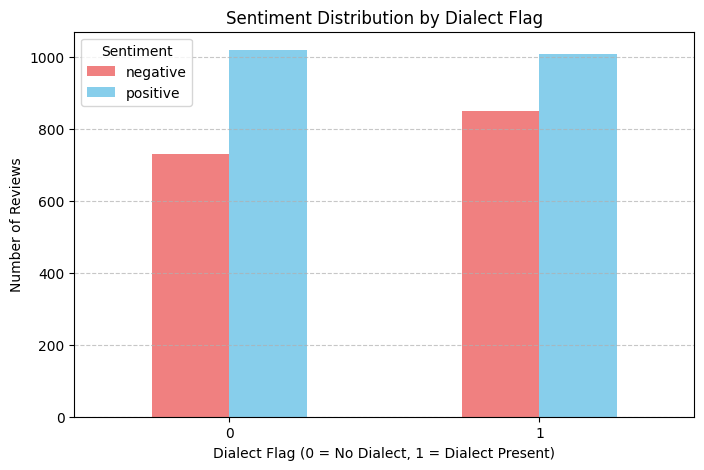

In [69]:
sentiment_by_dialect = df.groupby(['dialect_flag', 'sentiment']).size().unstack(fill_value=0)
display(sentiment_by_dialect)

import matplotlib.pyplot as plt
sentiment_by_dialect.plot(kind='bar', figsize=(8, 5), color=['lightcoral', 'skyblue'])
plt.title('Sentiment Distribution by Dialect Flag')
plt.xlabel('Dialect Flag (0 = No Dialect, 1 = Dialect Present)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This output shows the count of positive and negative reviews for each `dialect_flag` category. The bar chart provides a clear visual comparison of how sentiment is distributed across reviews identified with and without a specific dialect. This can be insightful for understanding potential biases or differences in linguistic expression related to sentiment.

## Step 3: Group Task (20 minutes)
Implement the analytical task, compare models, and discuss which representation or model performs best.

## Step 4: Research, Discussion & Reflection (30 minutes)
Discuss findings and record insights.

### Reflection Questions
1. What key insights were revealed through your evaluation process?
2. Which model or technique provided the best results, and why?
3. What were the main challenges faced during the analysis?
4. How do your findings demonstrate the bias-variance tradeoff?
5. What steps could improve model performance and reliability?

## Step 5: Wrap-Up (5 minutes)
Review core concepts as a class.

**Instructor Emphasizes**
- Even minor data flaws can lead to significant AI/ML errors.
- Data quality, preprocessing, and evaluation are equally important as algorithm choice.

## Submission and Reminders
- Submit a 1–2-page APA-formatted paper including embedded code, explanations, and screenshots of output.
- Include references and citations.
- Upload via Canvas LMS in Word or PDF format.
- **Due: Sunday, 11:59 PM.**